In [1]:
# Add repo root to sys.path so the package can be imported in-kernel
import sys
from pathlib import Path
# repo_root should point to the repository root (parent of RTD_Calibration_VGP)
repo_root = Path('..').resolve().parent if (Path('..').resolve().name == 'RTD_Calibration_VGP') else Path('..').resolve()
# ensure the repository root is the parent that contains RTD_Calibration_VGP
if (repo_root / 'RTD_Calibration_VGP').exists():
    sys.path.insert(0, str(repo_root))
    print('Inserted repo root into sys.path:', repo_root)
else:
    # fallback: insert the immediate parent and warn
    sys.path.insert(0, str(Path('..').resolve()))
    print('Warning: expected repo layout not found; inserted', Path('..').resolve(), 'into sys.path')

# Import local modules via package namespace
from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.run import Run
from RTD_Calibration_VGP.src.set import Set
import pandas as pd

# Read the logfile from repo data folder (guard if missing)
logfile_path = (repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv').resolve() if (repo_root / 'RTD_Calibration_VGP').exists() else (repo_root / 'data' / 'LogFile.csv').resolve()
if not logfile_path.exists():
    print(f'Warning: logfile not found at {logfile_path}. Create or provide RTD_Calibration_VGP/data/LogFile.csv before running data processing cells.')
    logfile_df = pd.DataFrame()
else:
    logfiles = Logfile(filepath=str(logfile_path))
    logfile_df = logfiles.log_file

# Select sets to process - todos los sets con datos disponibles
# Según config.yml: Round 1 (3-48, 59-60), Round 2 (49-55), Round 3 (57, 62), Round 4 (63)
selected_sets = list(range(3, 49)) + list(range(49, 56)) + [57, 59, 60, 62, 63]  # Todos los sets disponibles

# Use the external YAML config to load round info and sensor mappings
config_path = (repo_root / 'RTD_Calibration_VGP' / 'config' / 'config.yml').resolve()
if config_path.exists():
    print(f'Using config: {config_path}')
    set_instance = Set(logfile=logfile_df, config_path=str(config_path))
else:
    print(f'Warning: config.yml not found at {config_path}, using defaults')
    set_instance = Set(logfile=logfile_df)

# If logfile_df is empty the following calls will be no-ops or produce warnings
set_instance.group_runs_by_set(selected_sets=selected_sets)
set_instance.calculate_offsets_and_rms(selected_sets=selected_sets)
# Use outputs/ directory for generated plots
set_instance.offset_repeatability(selected_sets=selected_sets, ref=2, save_dir='outputs/plot_global_means')

# Weighted mean offsets and errors
calibration_constants, calibration_errors = set_instance.calculate_weighted_mean_offsets(selected_sets=selected_sets)

print('Set processing complete. You can now run the plotting cells to generate figures.')
print(f'Loaded {len(set_instance.set_rounds)} sets with round info from config.yml')

Inserted repo root into sys.path: /Users/vicky/Desktop/rtd-calibration-ana
CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.
Using config: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/config/config.yml

Processing CalibSetNumber: 3.0
    Excluded: 20220526_ln2_r48176_r48177_48060_48479_1_pre (contains 'pre' or 'st')
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_1_pre (contains 'pre' or 'st')
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_1 (marked as 'BAD' in Selection)
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_2_pre (contains 'pre' or 'st')
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_2 (marked as 'BAD' in Selection)
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_3 (marked as 'BAD' in Selection)
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_4_pre (contains 'pre' or 'st')
    Excluded: 20220531_ln2_r48176_r48177_48060_48479_4 (marked as 'BAD' in Selection)
    E

/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py:812: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(fontsize=8, loc="upper left", ncol=1)


Plot saved to: outputs/plot_global_means/offset_repeatability_set_30.png

Processing CalibSetNumber: 31
OK: Set 31: Using dynamic references from raised sensors in channels [3, 9]
  [Sensor Ch 1 vs Ref Ch 3 | Run 1] Mean: 253.407 mK, Std: 0.741 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 2] Mean: 250.278 mK, Std: 0.339 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 3] Mean: 245.080 mK, Std: 0.316 mK
  [Sensor Ch 1 vs Ref Ch 3 | Run 4] Mean: 245.703 mK, Std: 0.485 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 1] Mean: 227.953 mK, Std: 0.638 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 2] Mean: 230.148 mK, Std: 0.260 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 3] Mean: 228.734 mK, Std: 0.258 mK
  [Sensor Ch 2 vs Ref Ch 3 | Run 4] Mean: 229.655 mK, Std: 0.345 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 1] Mean: -284.920 mK, Std: 0.738 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 2] Mean: -287.318 mK, Std: 0.342 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 3] Mean: -283.702 mK, Std: 0.319 mK
  [Sensor Ch 3 vs Ref Ch 9 | Run 4] Mean: -286.864 mK, Std: 0.626 mK


Processing 56 sets.
Set 3: len sensor_names=9, len global_means=9
  First sensor_name: '48060' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-66.35545269405011) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 4: len sensor_names=9, len global_means=9
  First sensor_name: '48480' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-13.924798414992452) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 5: len sensor_names=10, len global_means=10
  First sensor_name: '48492' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-33.899152223248684) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 6: len sensor_names=9, len global_means=9
  First sensor_name: '48726' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-26.16033667765956) (type: <class 'numpy.float64'>)
  All glo

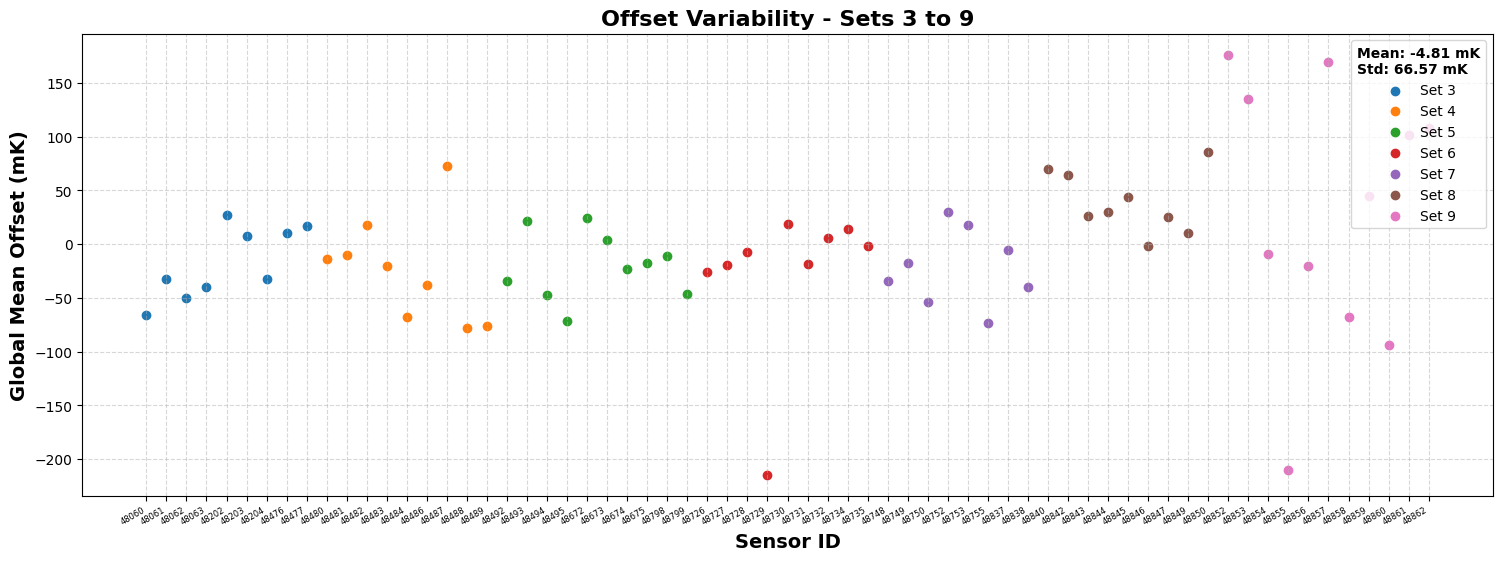

Set 10: len sensor_names=11, len global_means=11
  First sensor_name: '48864' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(510.161061460056) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 11: len sensor_names=11, len global_means=11
  First sensor_name: '48876' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(474.5711616109265) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 12: len sensor_names=11, len global_means=11
  First sensor_name: '48888' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-41.90747332782698) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 13: len sensor_names=11, len global_means=11
  First sensor_name: '48900' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-492.16611675545056) (type: <class 'numpy.float64'>)
  All global_mean types

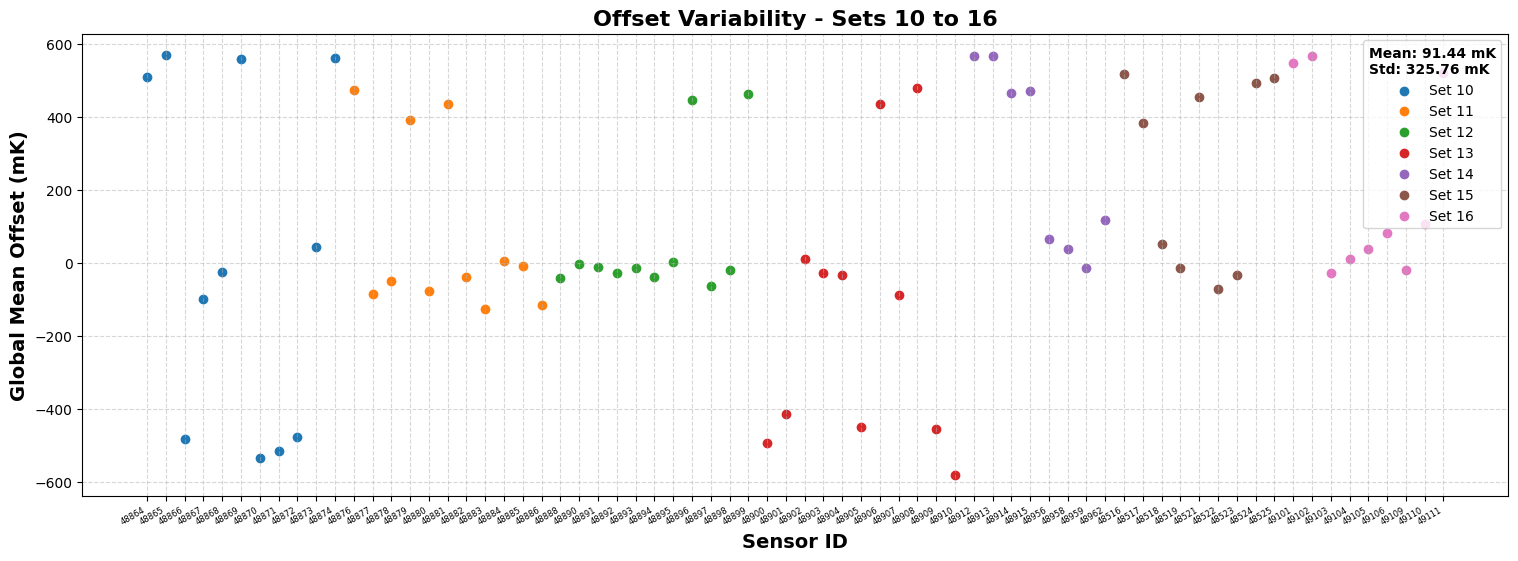

Set 17: len sensor_names=9, len global_means=9
  First sensor_name: '49113' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-402.586976713226) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 18: len sensor_names=10, len global_means=10
  First sensor_name: '49125' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(46.25990699789376) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 19: len sensor_names=10, len global_means=10
  First sensor_name: '49167' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-23.077077230149744) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 20: len sensor_names=11, len global_means=11
  First sensor_name: '49179' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-22.876541138700684) (type: <class 'numpy.float64'>)
  All global_mean types

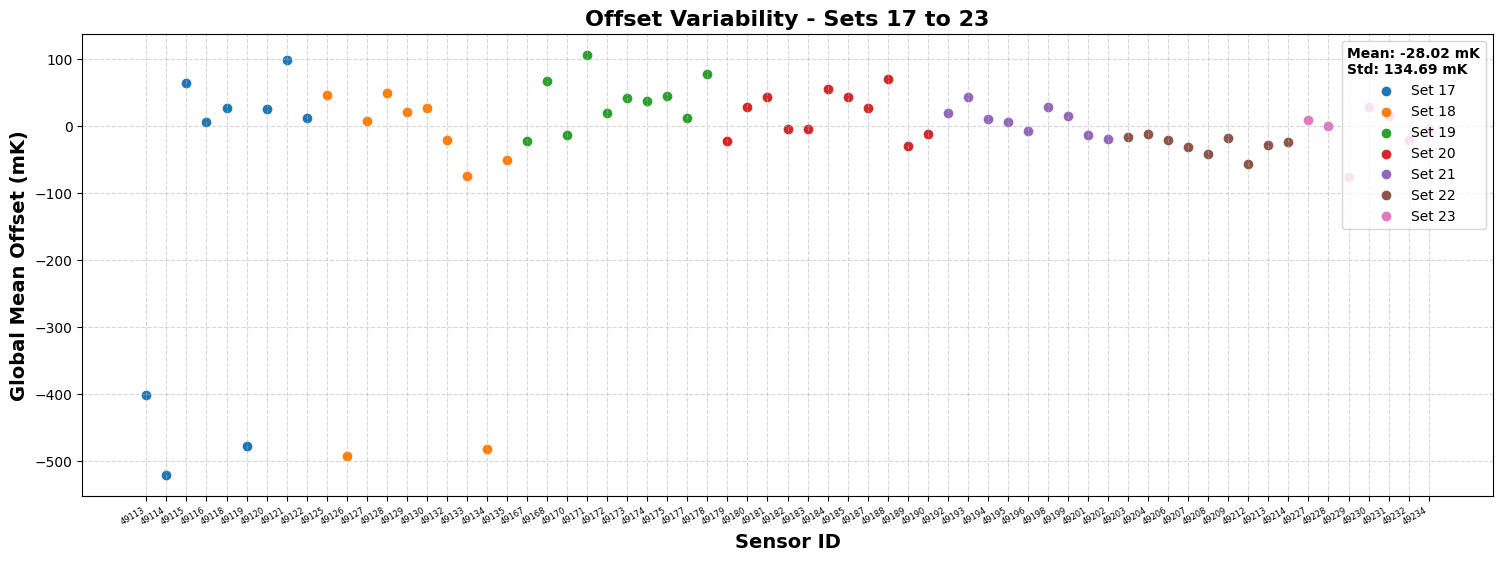

Set 24: len sensor_names=10, len global_means=10
  First sensor_name: '49238' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(43.43578343792494) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 25: len sensor_names=9, len global_means=9
  First sensor_name: '49250' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(5.353061249734044) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 26: len sensor_names=8, len global_means=8
  First sensor_name: '55069' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-75.36147611951102) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 27: len sensor_names=8, len global_means=8
  First sensor_name: '54880' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(18.509297143718772) (type: <class 'numpy.float64'>)
  All global_mean types: {'fl

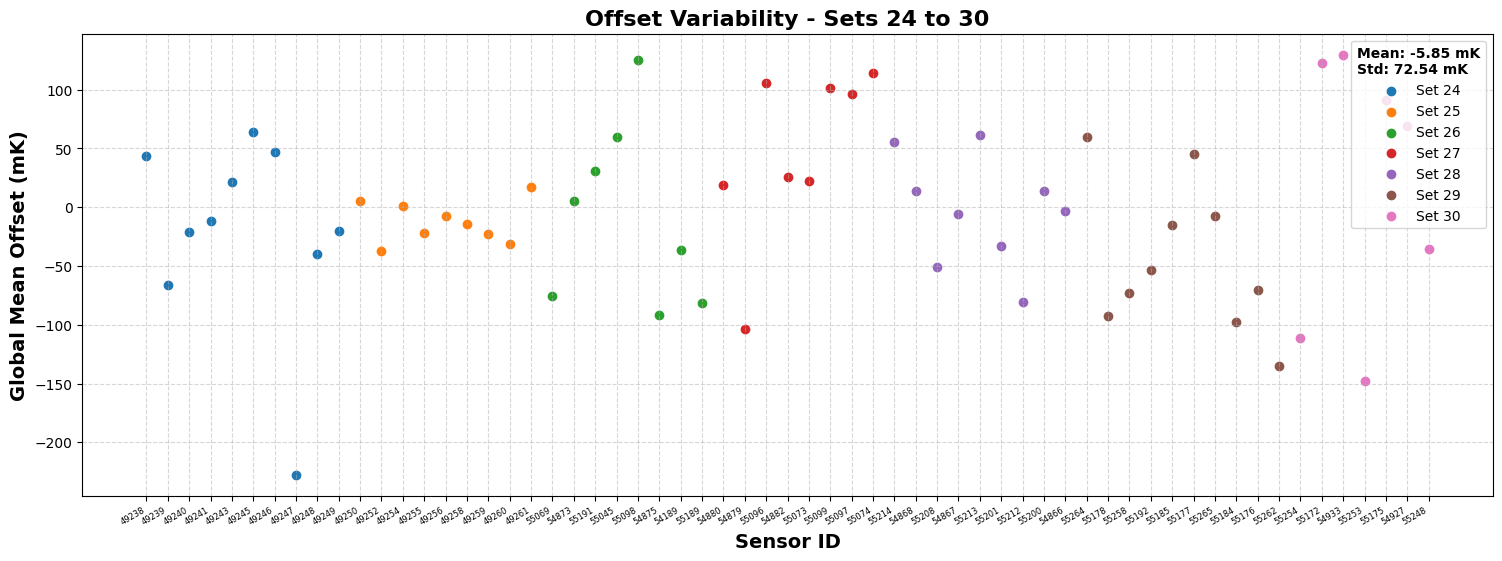

Set 31: len sensor_names=10, len global_means=10
  First sensor_name: '55179' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(229.39273056790006) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 32: len sensor_names=10, len global_means=10
  First sensor_name: '55247' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-43.748213067542714) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 33: len sensor_names=10, len global_means=10
  First sensor_name: '55167' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-94.67676104083002) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 34: len sensor_names=11, len global_means=11
  First sensor_name: '54878' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(20.90902421148625) (type: <class 'numpy.float64'>)
  All global_mean typ

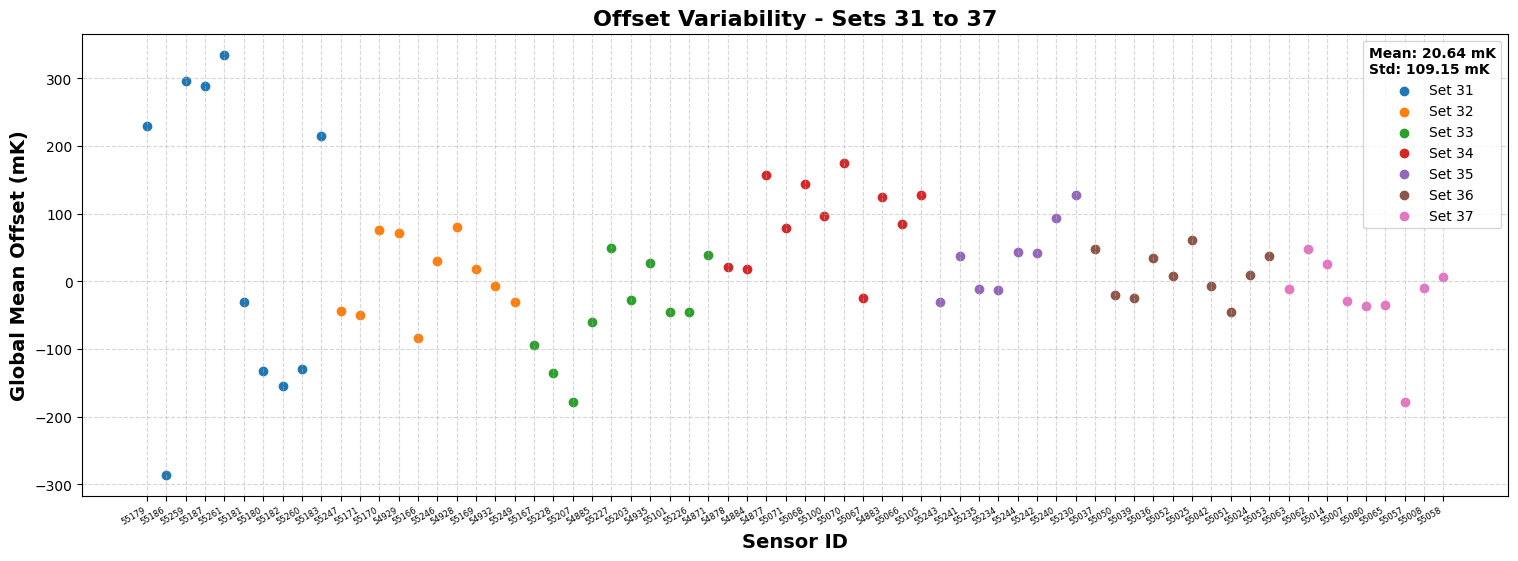

Set 38: len sensor_names=10, len global_means=10
  First sensor_name: '55218' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(35.93507613274094) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 39: len sensor_names=11, len global_means=11
  First sensor_name: '55238' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(102.02864675880144) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 40: len sensor_names=10, len global_means=10
  First sensor_name: '55206' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(96.61793022956275) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 41: len sensor_names=11, len global_means=11
  First sensor_name: '54896' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(746.1446600075965) (type: <class 'numpy.float64'>)
  All global_mean types:

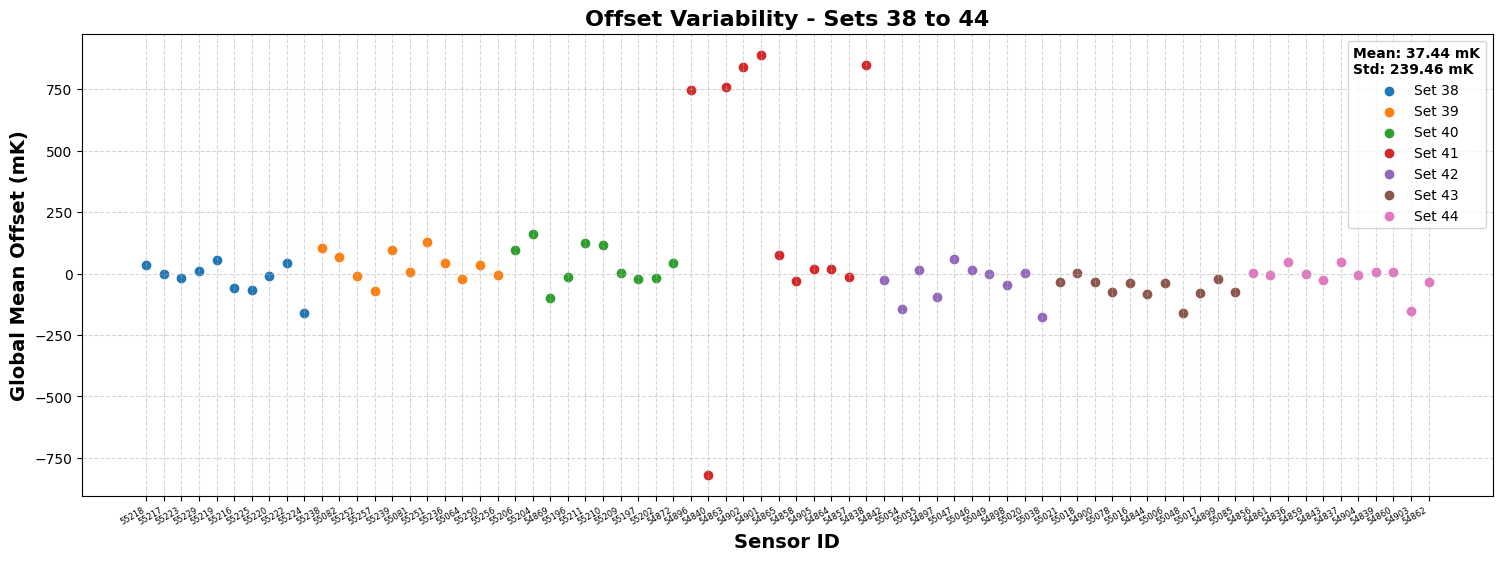

Set 45: len sensor_names=11, len global_means=11
  First sensor_name: '55056' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-12.841195984016062) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 46: len sensor_names=10, len global_means=10
  First sensor_name: '48957' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-593.6558416578946) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 47: len sensor_names=10, len global_means=10
  First sensor_name: '55190' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(3.777899346017095) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 48: len sensor_names=10, len global_means=10
  First sensor_name: '55231' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(162.17944770715914) (type: <class 'numpy.float64'>)
  All global_mean typ

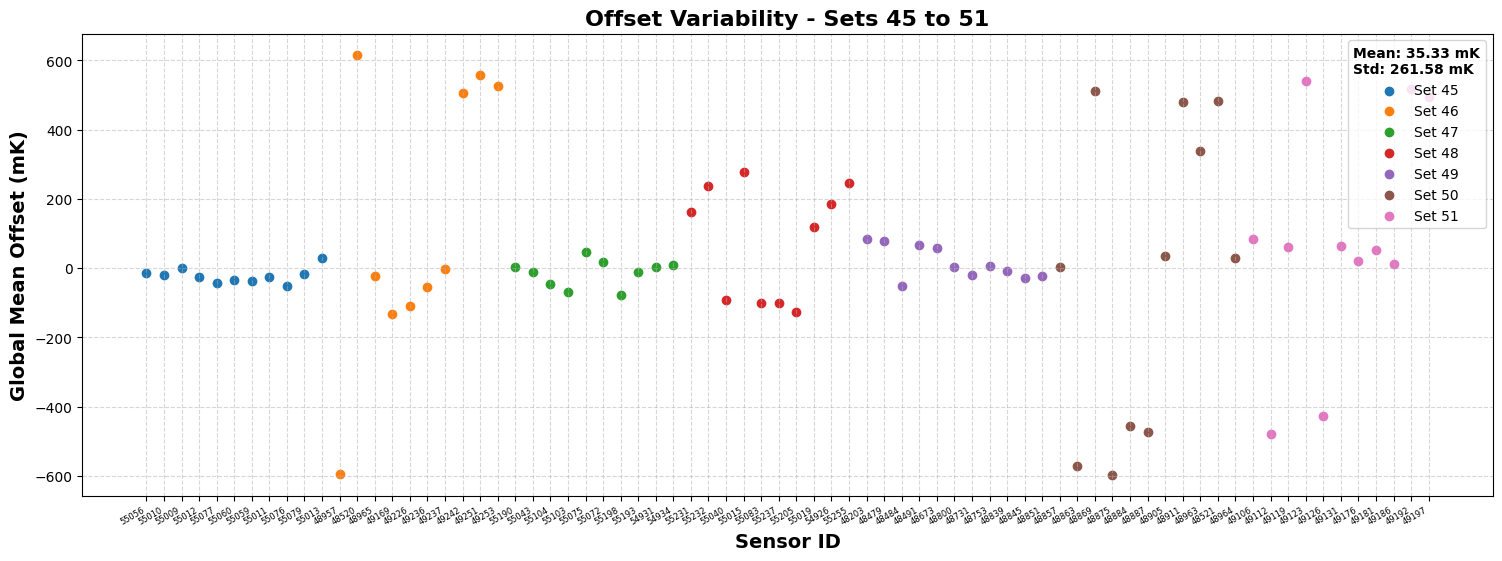

Set 52: len sensor_names=11, len global_means=11
  First sensor_name: '49204' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(557.4797904736711) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 53: len sensor_names=11, len global_means=11
  First sensor_name: '55208' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-75.87648906154745) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 54: len sensor_names=11, len global_means=11
  First sensor_name: '54876' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-32.02924497802756) (type: <class 'numpy.float64'>)
  All global_mean types: {'float64'}
Set 55: len sensor_names=11, len global_means=11
  First sensor_name: '54869' (type: <class 'str'>)
  All sensor_name types: {'str'}
  First global_mean: np.float64(-95.87204610846507) (type: <class 'numpy.float64'>)
  All global_mean type

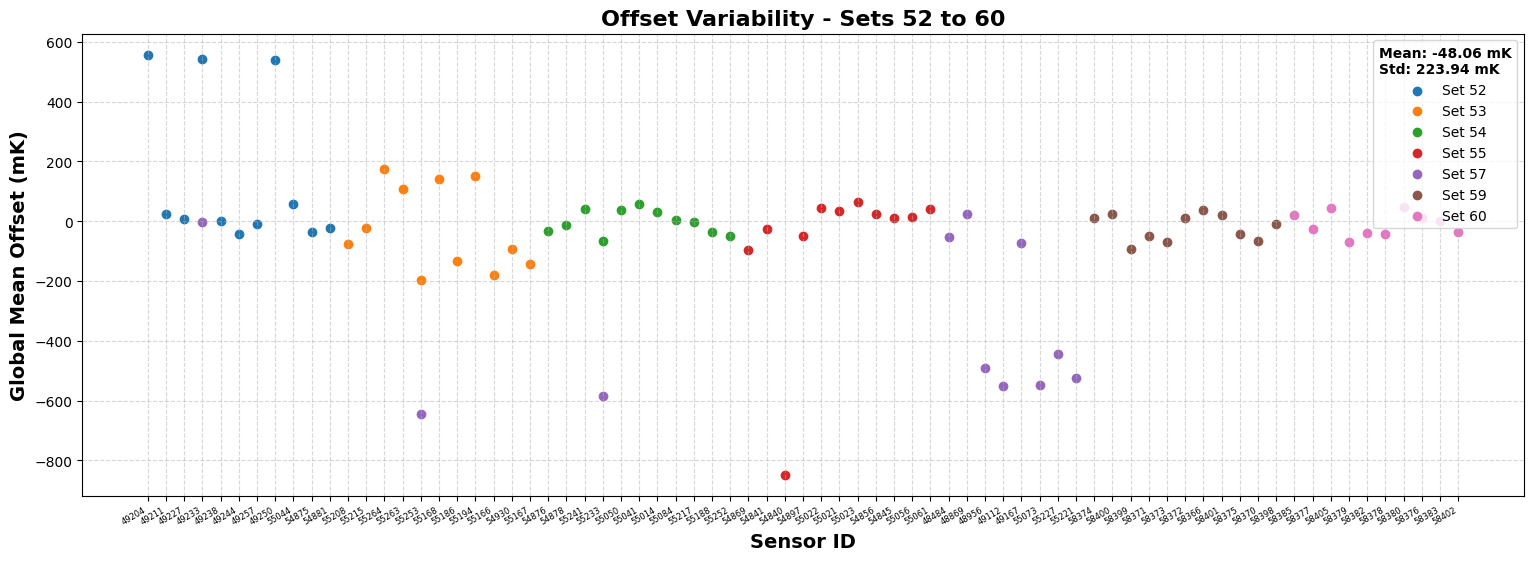

In [2]:
# 9. Plot the global mean of offsets per sensor
set_instance.plot_global_means(selected_sets=selected_sets)
# set_instance.plot_global_means()

Processing 56 sets.


/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/set.py:1555: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=legend_title, title_fontproperties={'weight': 'bold'}, loc='upper left')


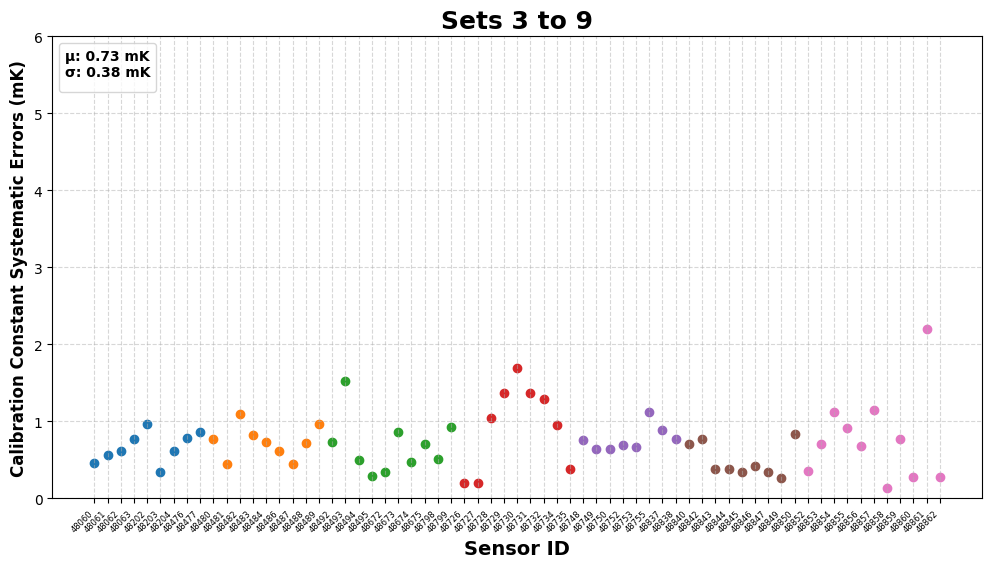

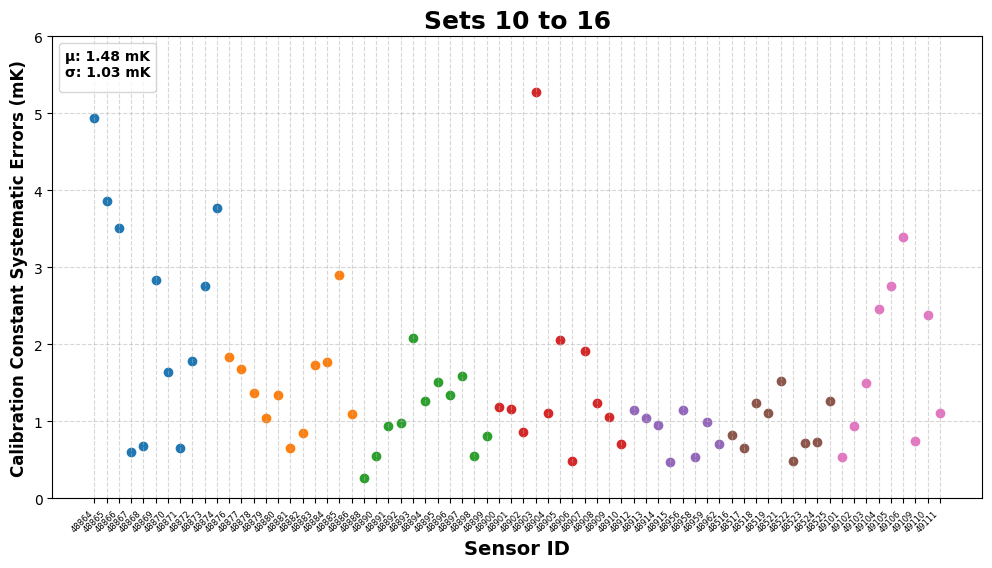

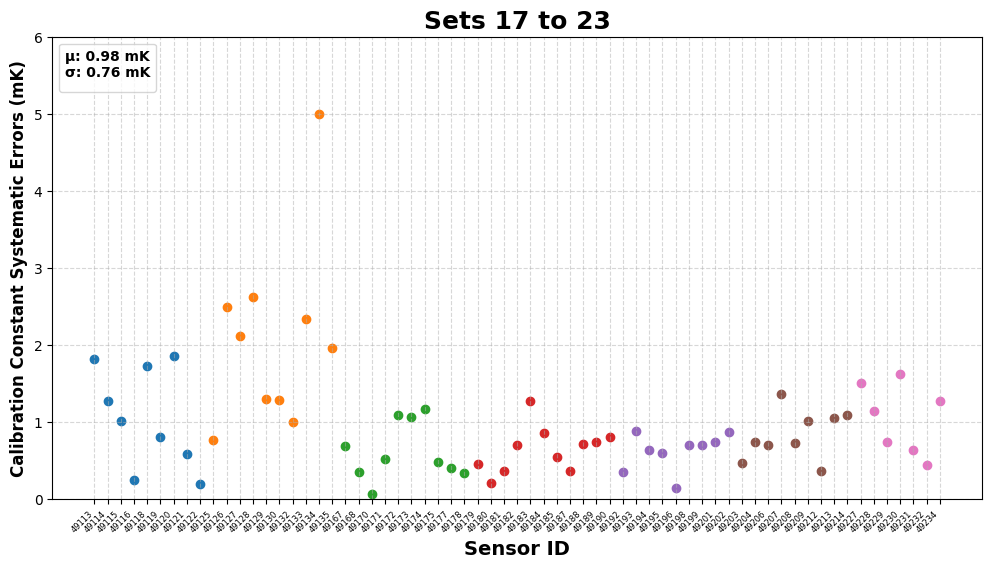

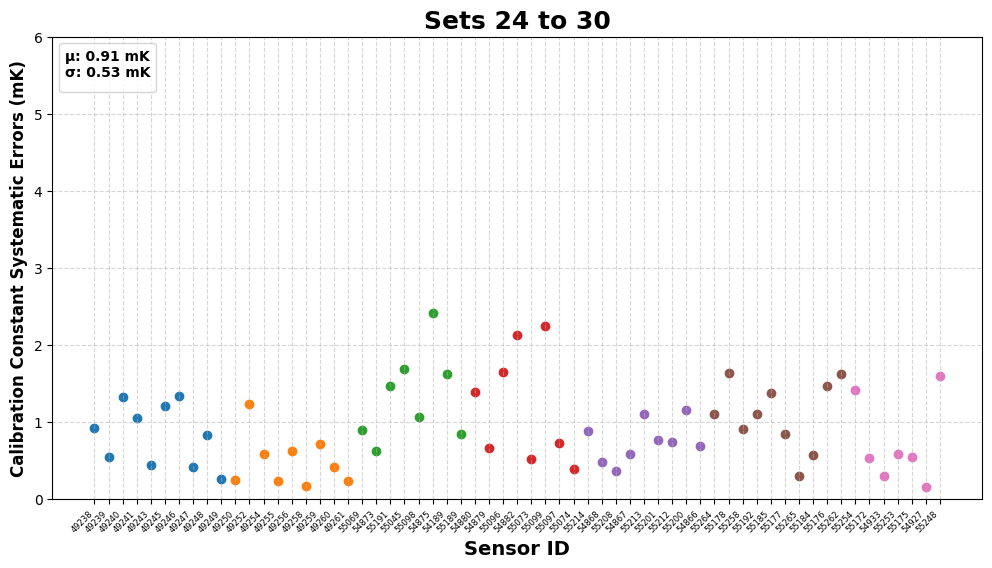

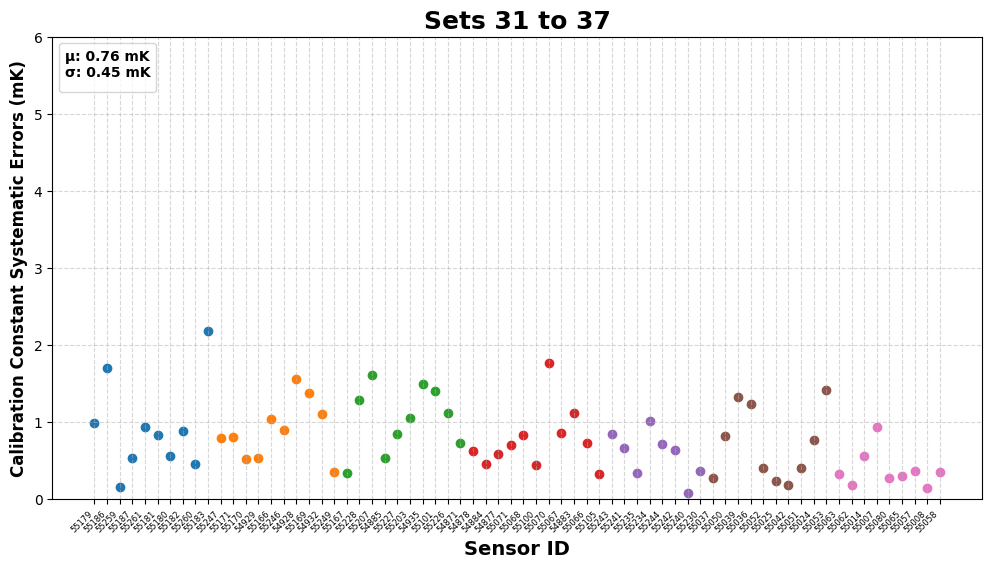

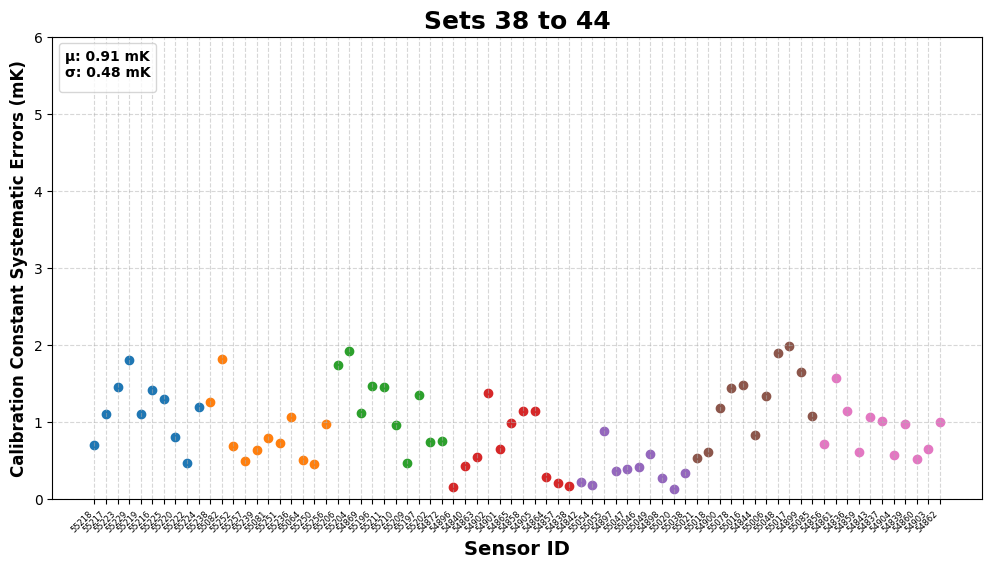

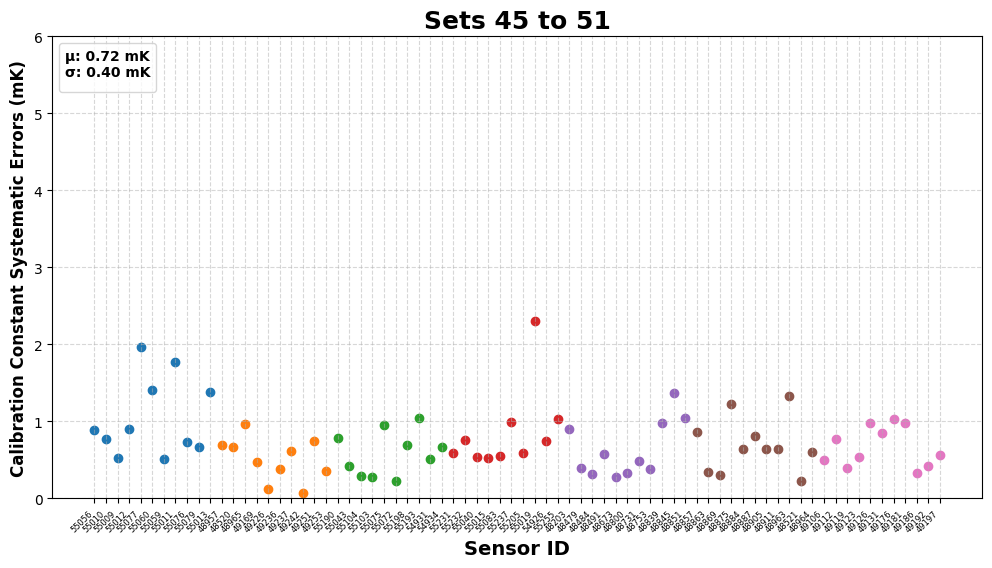

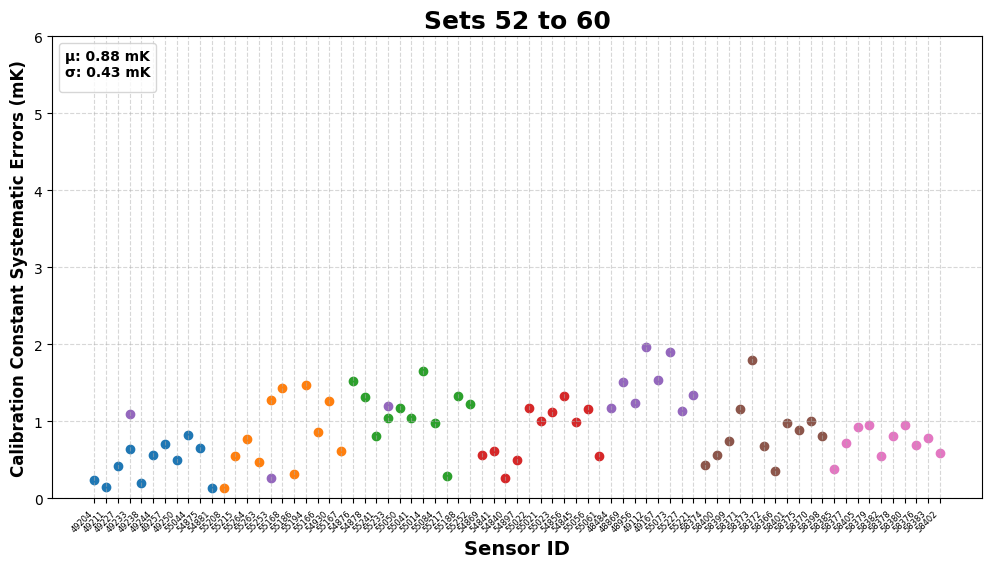

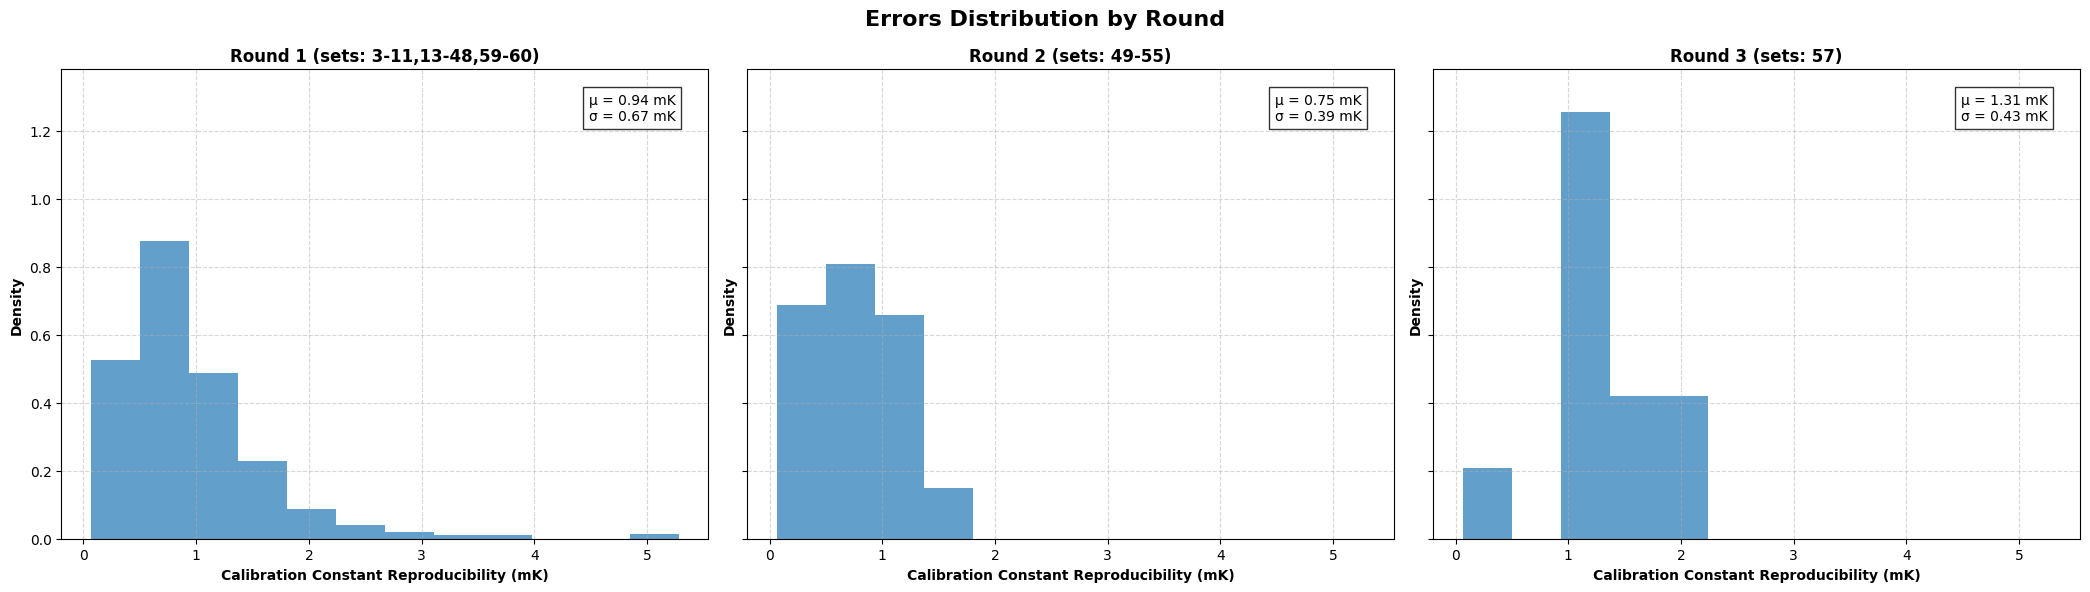

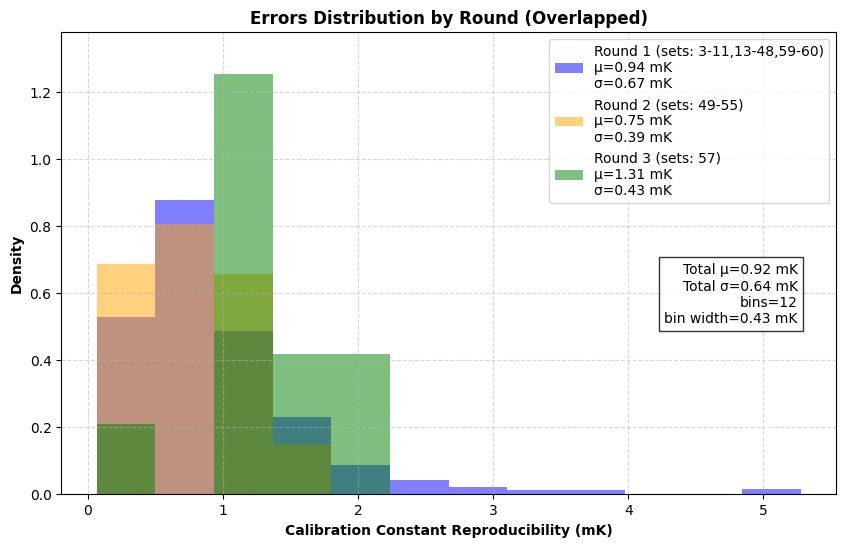

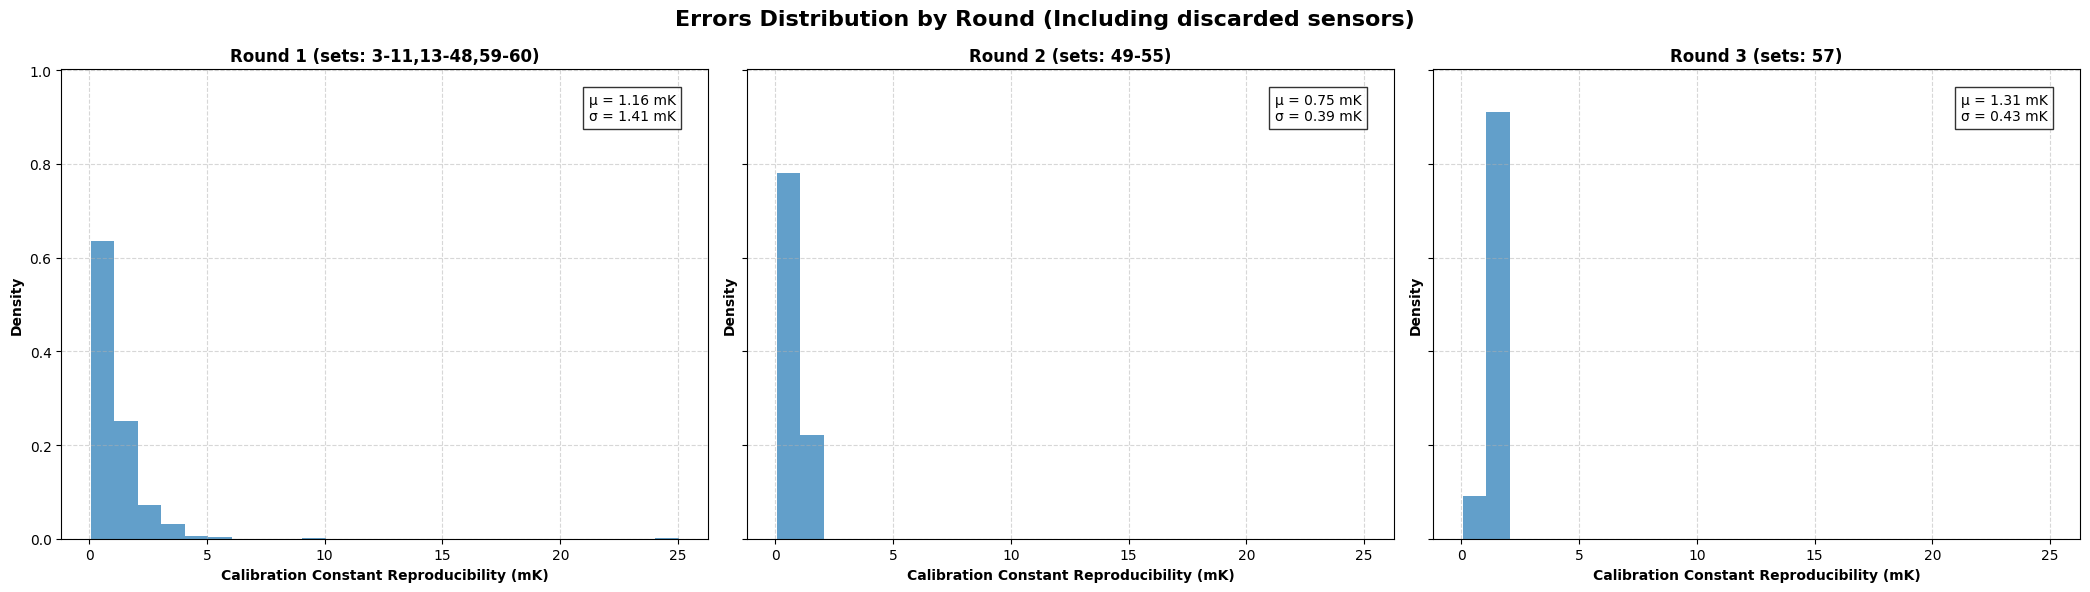

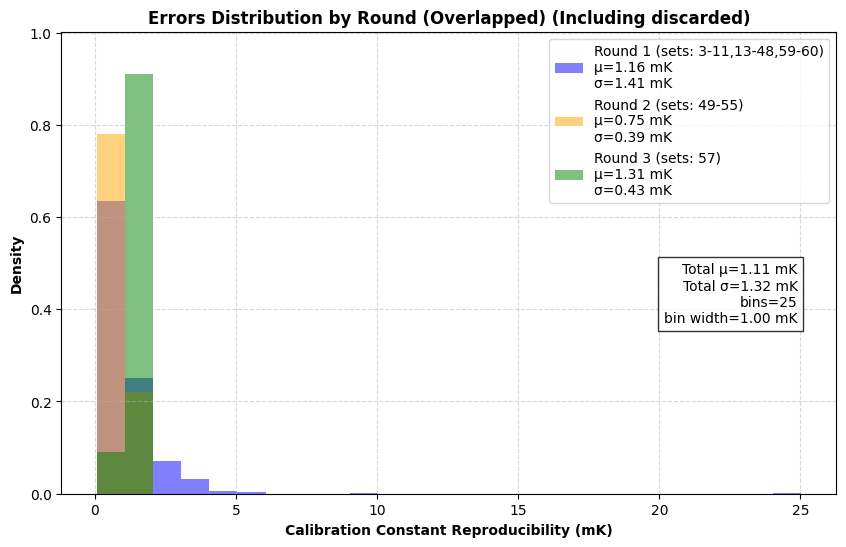

In [3]:
# 11. Generar histogramas por ronda con más bins
# Los histogramas incluyen:
# - Distribuciones por ronda (separadas y overlapped)
# - Comparación Round 1 vs Rounds 2+3 (overlapped)
# - Versiones con y sin sensores descartados (20 bins vs 12 bins)
set_instance.plot_global_sigmas(selected_sets=selected_sets, save_dir='outputs/histograms_by_round')

## Histogramas de Distribución de Errores por Ronda

Los histogramas a continuación muestran:

1. **Distribución por ronda**: Subplots separados y gráficos overlapped para todas las rondas (1, 2, 3, 4)
2. **Comparación Round 1 vs Rounds 2+3**: Gráficos overlapped específicos para comparar la primera ronda contra las rondas de re-calibración
3. **Versiones con y sin sensores descartados**: 
   - Sin descartados: 12 bins
   - Con descartados: 20 bins (mayor resolución para ver distribución completa)

La información de rondas se carga desde `config.yml`.

In [4]:
# Mostrar información sobre las rondas cargadas desde config.yml
import pandas as pd

if hasattr(set_instance, 'set_rounds') and set_instance.set_rounds:
    rounds_df = pd.DataFrame([
        {'CalibSetNumber': set_num, 'Round': round_num} 
        for set_num, round_num in set_instance.set_rounds.items()
    ]).sort_values('CalibSetNumber')
    
    print("Información de rondas desde config.yml:")
    print("-" * 50)
    for round_num in sorted(rounds_df['Round'].unique()):
        sets_in_round = rounds_df[rounds_df['Round'] == round_num]['CalibSetNumber'].astype(int).tolist()
        print(f"Round {round_num}: {len(sets_in_round)} sets -> {sets_in_round}")
    print("-" * 50)
    print(f"\nTotal: {len(rounds_df)} sets con información de ronda")
else:
    print("No se encontró información de rondas en la instancia de Set")

Información de rondas desde config.yml:
--------------------------------------------------
Round 1: 48 sets -> [3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 59, 60, 61]
Round 2: 8 sets -> [49, 50, 51, 52, 53, 54, 55, 56]
Round 3: 2 sets -> [57, 62]
Round 4: 1 sets -> [63]
--------------------------------------------------

Total: 59 sets con información de ronda


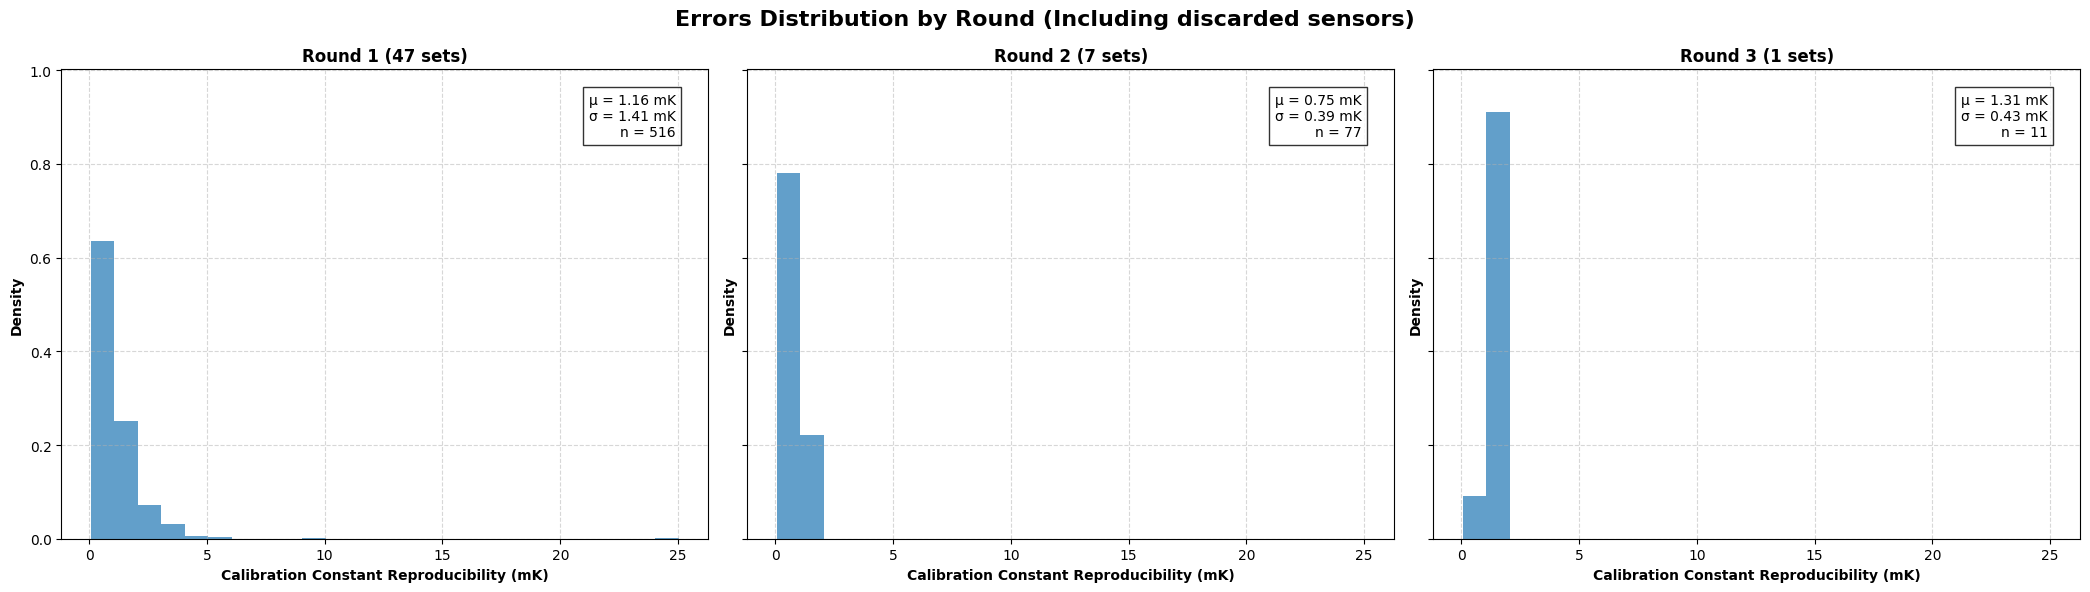

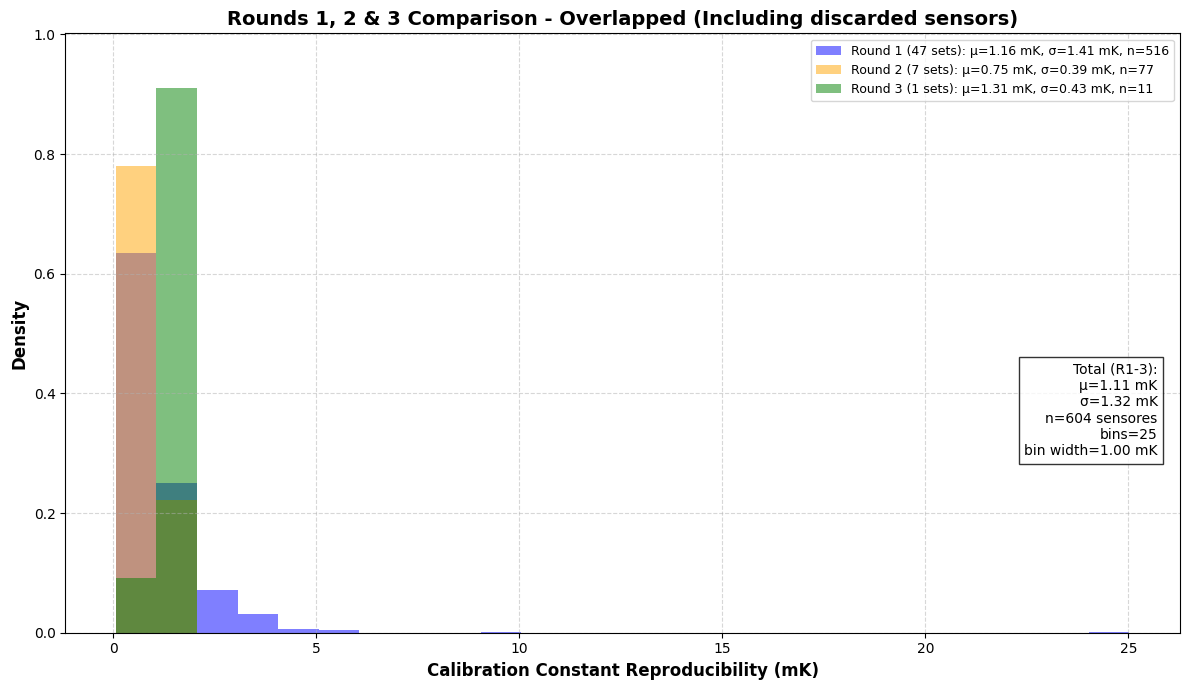


📊 Resumen de datos:
  Round 1: 516 sensores en 47 sets
  Round 2: 77 sensores en 7 sets
  Round 3: 11 sensores en 1 sets
  Total (todas las rondas): 604 sensores
  Rango de datos: 0.06 - 25.02 mK (24.96 mK)
  Bins usados: 25
  Ancho de cada bin: 1.00 mK


In [5]:
# CÓDIGO CORREGIDO PARA LA CELDA DE HISTOGRAMAS CON DESCARTADOS
# Copia y pega este código COMPLETO en la celda del notebook

# Histograma overlapped de todas las rondas INCLUYENDO sensores descartados
import matplotlib.pyplot as plt
import numpy as np

def plot_all_rounds_overlapped_with_discarded():
    """Genera histograma overlapped de todas las rondas incluyendo sensores descartados"""
    
    # Función auxiliar para recoger sigmas (incluyendo descartados)
    def collect_sigmas_all(sets):
        sigmas_list = []
        for s in sets:
            if s not in set_instance.global_stats:
                continue
            sensors_data = set_instance.global_stats[s]
            example_run = next(iter(set_instance.runs_by_set[s].values()), None)
            channel_to_id = {}
            if example_run and example_run.sensor_mapping:
                channel_to_id = {int(k.replace("channel_", "")) - 1: int(v) for k, v in example_run.sensor_mapping.items()}
            
            # Excluir solo los dos últimos canales (referencias)
            ultimos_canales = [channel_to_id.get(12), channel_to_id.get(13)]
            
            for k in sensors_data.keys():
                if not str(k).isdigit():
                    continue
                sid = int(k)
                sid_mapped = channel_to_id.get(sid, sid) if channel_to_id else sid
                
                # Solo excluir canales de referencia
                if sid_mapped in ultimos_canales:
                    continue
                
                sigma = sensors_data[k].get("sigma")
                if sigma is not None and pd.notnull(sigma) and np.isfinite(sigma):
                    sigmas_list.append(sigma)
        return sigmas_list
    
    # Obtener sets disponibles
    available_sets = set(set_instance.global_stats.keys())
    
    # Agrupar por ronda usando set_rounds si está disponible (igual que en set.py)
    rounds_map = {}
    if hasattr(set_instance, "set_rounds") and set_instance.set_rounds:
        # Usar la configuración de set_rounds (incluye Round 4)
        for s, r in set_instance.set_rounds.items():
            if s in available_sets:
                rounds_map.setdefault(int(r), []).append(s)
    else:
        # Fallback manual (incluye Round 4)
        rounds_map = {
            1: [s for s in available_sets if 3 <= int(s) <= 48 or int(s) in [59, 60, 61]],
            2: [s for s in available_sets if 49 <= int(s) <= 55],
            3: [s for s in available_sets if int(s) in [57, 62]],
            4: [s for s in available_sets if int(s) == 63],
        }
    
    # Recoger sigmas por ronda (dinámico para todas las rondas disponibles)
    rounds_data = {}
    all_sigmas = []
    for rnum, sets_list in sorted(rounds_map.items()):
        if not sets_list:  # Saltar rondas sin sets
            continue
        sigmas = collect_sigmas_all(sets_list)
        if sigmas:  # Solo agregar si hay datos
            rounds_data[rnum] = {
                'sets': sets_list,
                'sigmas': sigmas,
                'mu': float(np.nanmean(sigmas)),
                'sigma': float(np.nanstd(sigmas))
            }
            all_sigmas.extend(sigmas)
    
    # Verificar que hay datos
    if not all_sigmas:
        print("No hay datos disponibles para generar el histograma")
        return
    
    # Calcular estadísticas totales
    mu_total = float(np.nanmean(all_sigmas))
    sigma_total = float(np.nanstd(all_sigmas))
    
    # Usar cálculo dinámico de bins: 1 bin por mK (igual que en set.py)
    # El rango determina cuántos bins necesitamos (ej: rango de 30 mK = 30 bins)
    data_range = max(all_sigmas) - min(all_sigmas)
    n_bins = max(int(np.ceil(data_range)), 20)  # At least 20 bins
    bins = np.histogram_bin_edges(all_sigmas, bins=n_bins)
    
    # Verificar ancho de bin real
    bin_width = bins[1] - bins[0] if len(bins) > 1 else 0
    
    # Calcular ymax para todos los histogramas
    ymax = 0
    for rdata in rounds_data.values():
        hist = np.histogram(rdata['sigmas'], bins=bins, density=True)[0]
        ymax = max(ymax, hist.max())
    ymax *= 1.1
    
    # ==========================================
    # PLOT 1: Subplots separados por ronda
    # ==========================================
    n_rounds = len(rounds_data)
    
    if n_rounds > 0:
        # Crear grid óptima: 1 fila si n<=3, 2 filas si n==4
        if n_rounds <= 3:
            nrows, ncols = 1, n_rounds
        else:  # n_rounds == 4
            nrows, ncols = 2, 2
        
        fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows), sharey=True, squeeze=False)
        axes = axes.flatten()
        
        fig.suptitle("Errors Distribution by Round (Including discarded sensors)",
                     fontsize=16, fontweight='bold')
        
        # Plotear solo las rondas con datos
        for idx, (rnum, rdata) in enumerate(sorted(rounds_data.items())):
            ax = axes[idx]
            ax.hist(rdata['sigmas'], bins=bins, alpha=0.7, density=True)
            ax.set_title(f"Round {rnum} ({len(rdata['sets'])} sets)", fontweight='bold')
            ax.set_xlabel("Calibration Constant Reproducibility (mK)", fontweight='bold')
            ax.set_ylabel("Density", fontweight='bold')
            ax.text(0.95, 0.95, f"μ = {rdata['mu']:.2f} mK\nσ = {rdata['sigma']:.2f} mK\nn = {len(rdata['sigmas'])}",
                    ha='right', va='top', transform=ax.transAxes, fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.8))
            ax.set_ylim(0, ymax)
            ax.grid(True, linestyle="--", alpha=0.5)
        
        # Ocultar subplots sobrantes (solo si n_rounds == 4 y hay subplot vacío)
        for idx in range(n_rounds, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    # ==========================================
    # PLOT 2: Overlapped (solo Rounds 1, 2, 3)
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(12, 7))
    
    # Colores para hasta 4 rondas
    colors = ['blue', 'orange', 'green', 'red']
    
    # Plotear histogramas overlapped solo para rounds 1, 2, 3
    for rnum in [1, 2, 3]:
        if rnum in rounds_data:
            rdata = rounds_data[rnum]
            color = colors[rnum - 1]
            ax2.hist(rdata['sigmas'], bins=bins, alpha=0.5, color=color, density=True,
                   label=f"Round {rnum} ({len(rdata['sets'])} sets): μ={rdata['mu']:.2f} mK, σ={rdata['sigma']:.2f} mK, n={len(rdata['sigmas'])}")
        else:
            # Añadir entrada de leyenda sin datos
            color = colors[rnum - 1]
            ax2.plot([], [], color=color, alpha=0.5, linewidth=10,
                   label=f"Round {rnum} (0 sets): No data")
    
    ax2.set_xlabel("Calibration Constant Reproducibility (mK)", fontweight='bold', fontsize=12)
    ax2.set_ylabel("Density", fontweight='bold', fontsize=12)
    ax2.set_ylim(0, ymax)
    ax2.set_title("Rounds 1, 2 & 3 Comparison - Overlapped (Including discarded sensors)", 
                fontweight='bold', fontsize=14)
    ax2.grid(True, linestyle="--", alpha=0.5)
    ax2.legend(loc='upper right', fontsize=9)
    
    # Añadir estadísticas totales (solo rounds 1-3)
    sigmas_123 = []
    for rnum in [1, 2, 3]:
        if rnum in rounds_data:
            sigmas_123.extend(rounds_data[rnum]['sigmas'])
    mu_123 = float(np.nanmean(sigmas_123)) if sigmas_123 else 0
    sigma_123 = float(np.nanstd(sigmas_123)) if sigmas_123 else 0
    
    ax2.text(0.98, 0.45,
           f"Total (R1-3):\nμ={mu_123:.2f} mK\nσ={sigma_123:.2f} mK\nn={len(sigmas_123)} sensores\nbins={n_bins}\nbin width={bin_width:.2f} mK",
           ha='right', va='top', transform=ax2.transAxes,
           fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Resumen de datos:")
    for rnum, rdata in sorted(rounds_data.items()):
        print(f"  Round {rnum}: {len(rdata['sigmas'])} sensores en {len(rdata['sets'])} sets")
    print(f"  Total (todas las rondas): {len(all_sigmas)} sensores")
    print(f"  Rango de datos: {min(all_sigmas):.2f} - {max(all_sigmas):.2f} mK ({data_range:.2f} mK)")
    print(f"  Bins usados: {n_bins}")
    print(f"  Ancho de cada bin: {bin_width:.2f} mK")

# Ejecutar
plot_all_rounds_overlapped_with_discarded()
